In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Diwali_Sales_Data.csv', encoding='unicode_escape')


In [4]:
df.shape

(11251, 15)

In [5]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [10]:
df['Amount'] = df['Amount'].astype('int')

In [11]:
df['Amount'].dtype

dtype('int64')

In [12]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# **Exploratory Data Analysis**

**Gender**

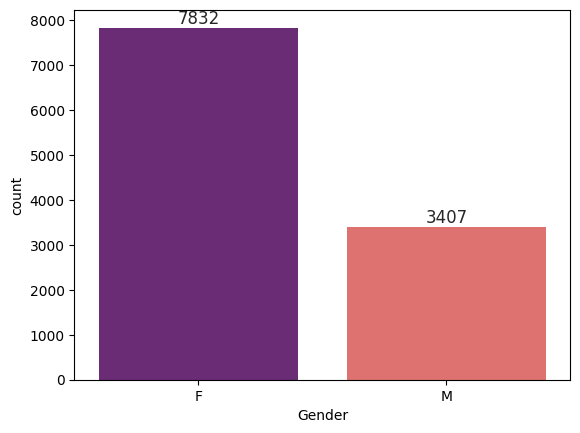

In [13]:
ax = sns.countplot(x = 'Gender',data = df,hue='Gender',palette='magma',legend=False)

sns.set(rc={'figure.figsize':(6.4,4.8)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

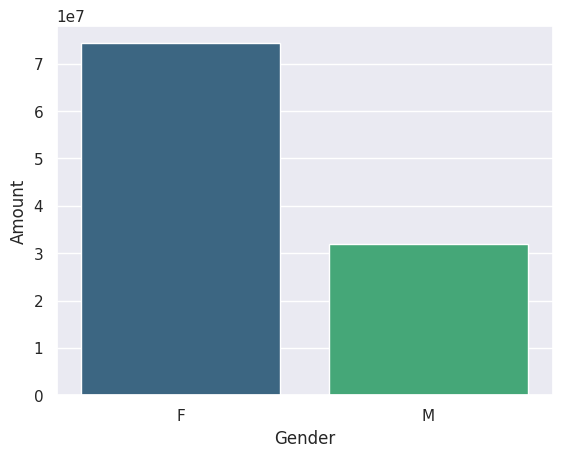

In [14]:
Sales_gen = df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.set(rc={'figure.figsize':(6.4,4.8)})
sns.barplot(x = 'Gender',y= 'Amount' , data = Sales_gen, hue='Gender', palette='viridis')

*From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men*

 **Age**

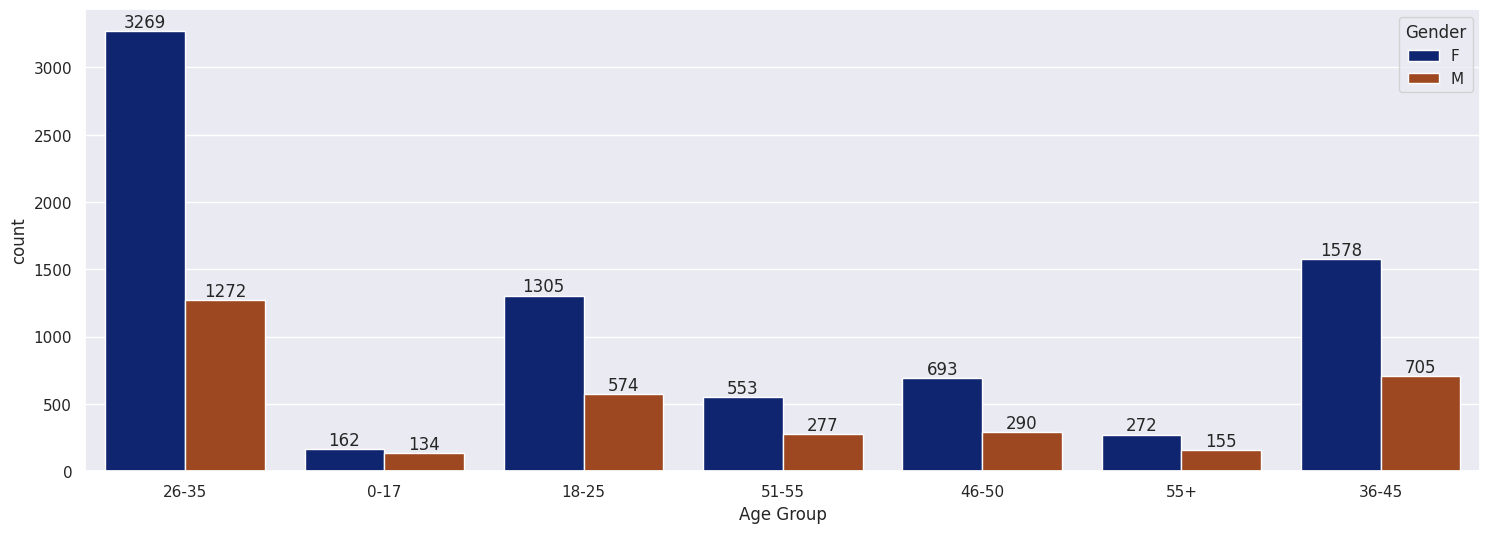

In [19]:
ax = sns.countplot(x = 'Age Group',hue='Gender',data=df,palette='dark')

sns.set(rc={'figure.figsize':(15,6)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

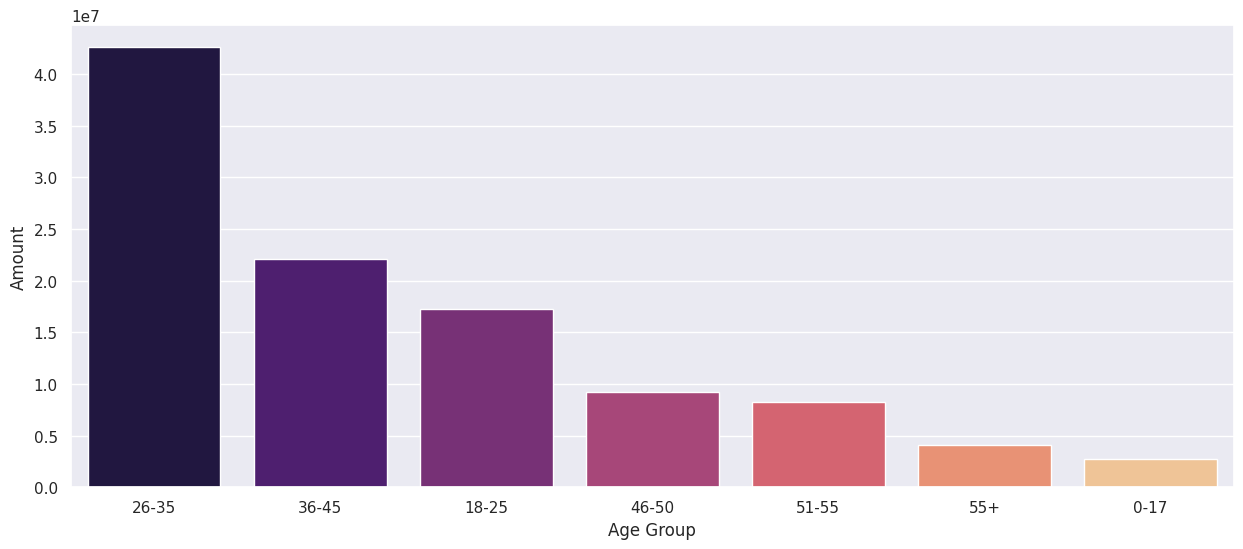

In [20]:
sales_age = df.groupby(['Age Group'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(x = 'Age Group',y= 'Amount',data=sales_age,hue='Age Group',palette='magma')

*From above graphs we can see that most of the buyers are of age group between 26-35 yrs female*

 **State**

<Axes: xlabel='State', ylabel='Orders'>

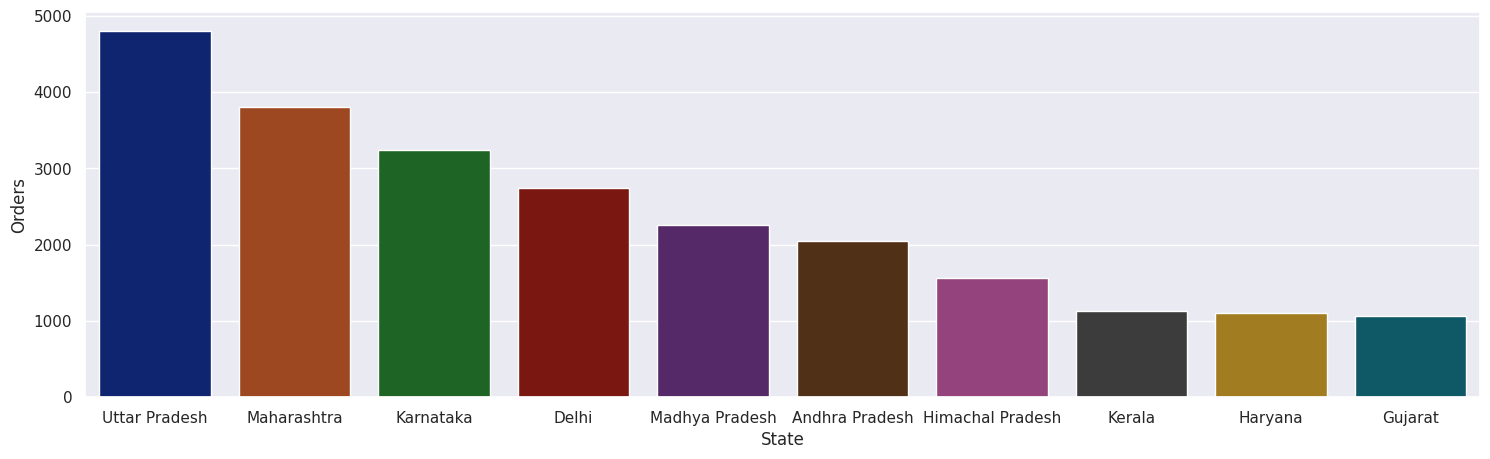

In [21]:
Sales_state=df.groupby(['State'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)

sns.set(rc={'figure.figsize':(18,5)})
sns.barplot(data=Sales_state,x='State',y='Orders',hue='State',palette='dark')

<Axes: xlabel='State', ylabel='Amount'>

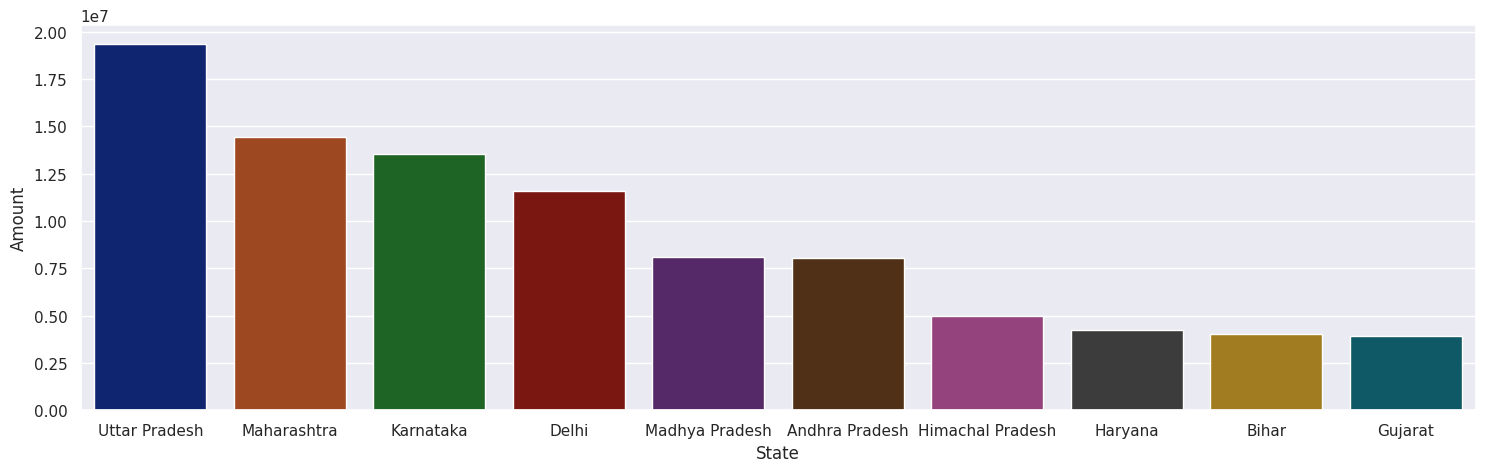

In [22]:
Sales_state=df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)

sns.set(rc={'figure.figsize':(18,5)})
sns.barplot(data=Sales_state,x='State',y='Amount',hue='State',palette='dark')

*From above graphs we can see that unexpectedly most of the orders are from Uttar Pradesh, Maharashtra and Karnataka respectively but total sales/amount is from UP, Karnataka and then Maharashtra *



**Marital Status**

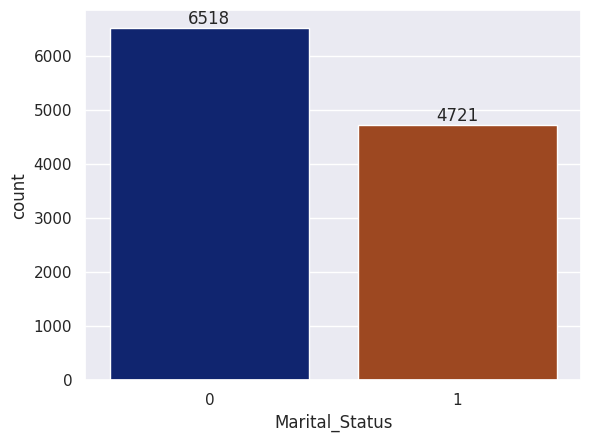

In [24]:
ax = sns.countplot(data=df,x='Marital_Status',hue='Marital_Status',palette='dark',legend=False)

sns.set(rc={'figure.figsize':(6.4,4.8)})
for bars in ax.containers:
  ax.bar_label(bars)


<Axes: xlabel='Marital_Status', ylabel='Amount'>

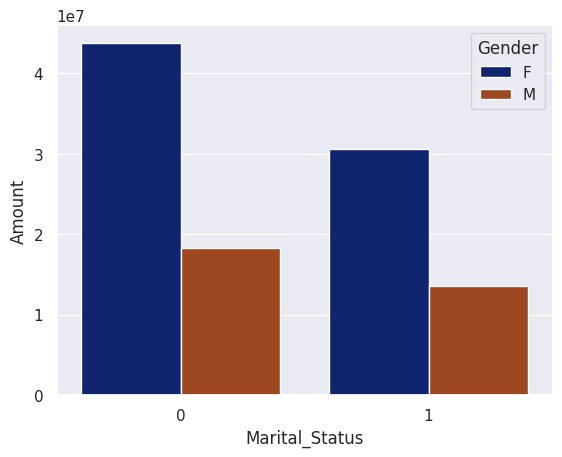

In [25]:
Sales_state = df.groupby(['Marital_Status','Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(data=Sales_state,x='Marital_Status',y='Amount',hue='Gender',palette='dark')

*From above graphs we can see that most of the buyers are married (Women) and they have high purchasing power *

**Occupation**

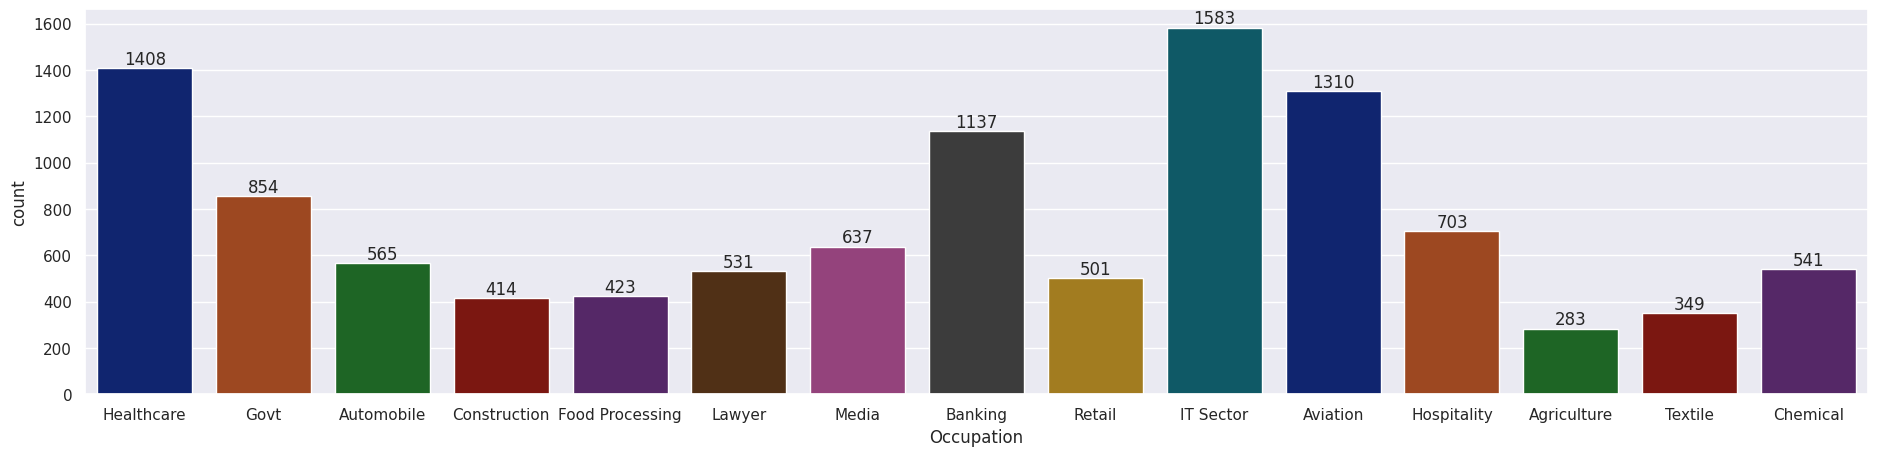

In [27]:
ax = sns.countplot(data=df,x='Occupation',hue='Occupation',palette='dark',legend=False)

sns.set(rc={'figure.figsize':(23,5)})
for bars in ax.containers:
  ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

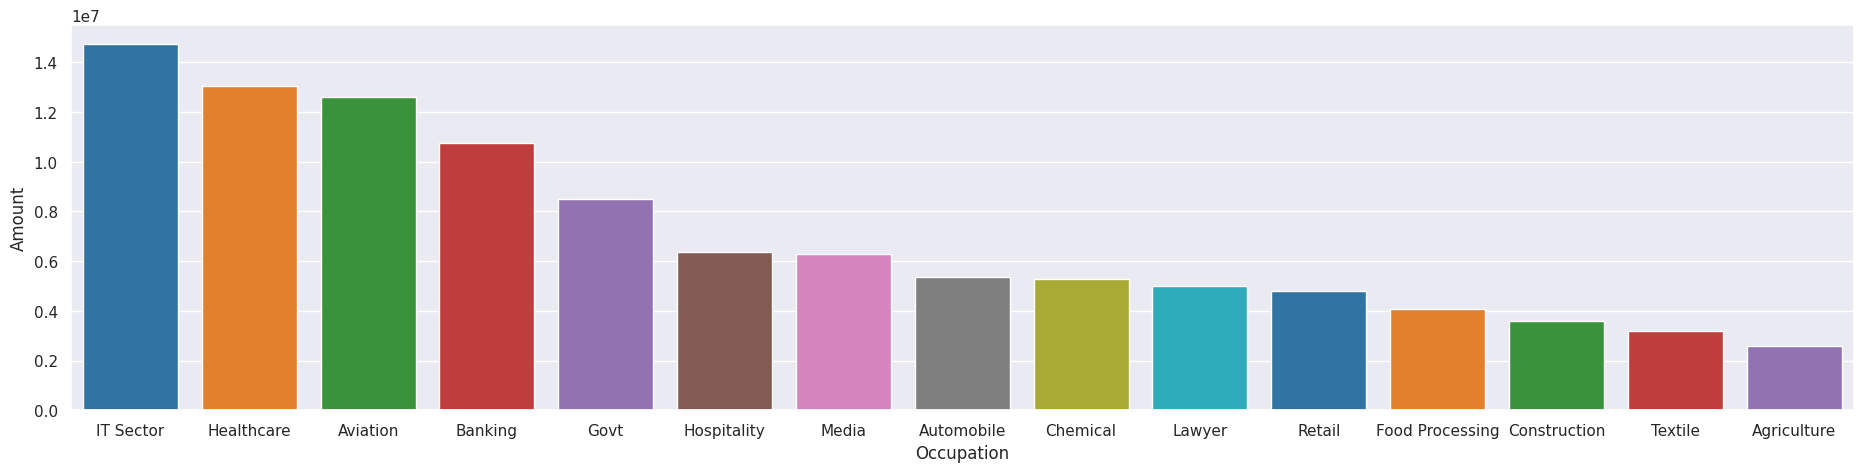

In [ ]:
Sales_oc = df.groupby(['Occupation'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(data=Sales_oc,x='Occupation',y='Amount',hue='Occupation',palette='tab10')

*From above graphs we can see that nost of the buyers are working in IT, Aviation and Healthcare sector*

**Product Category**

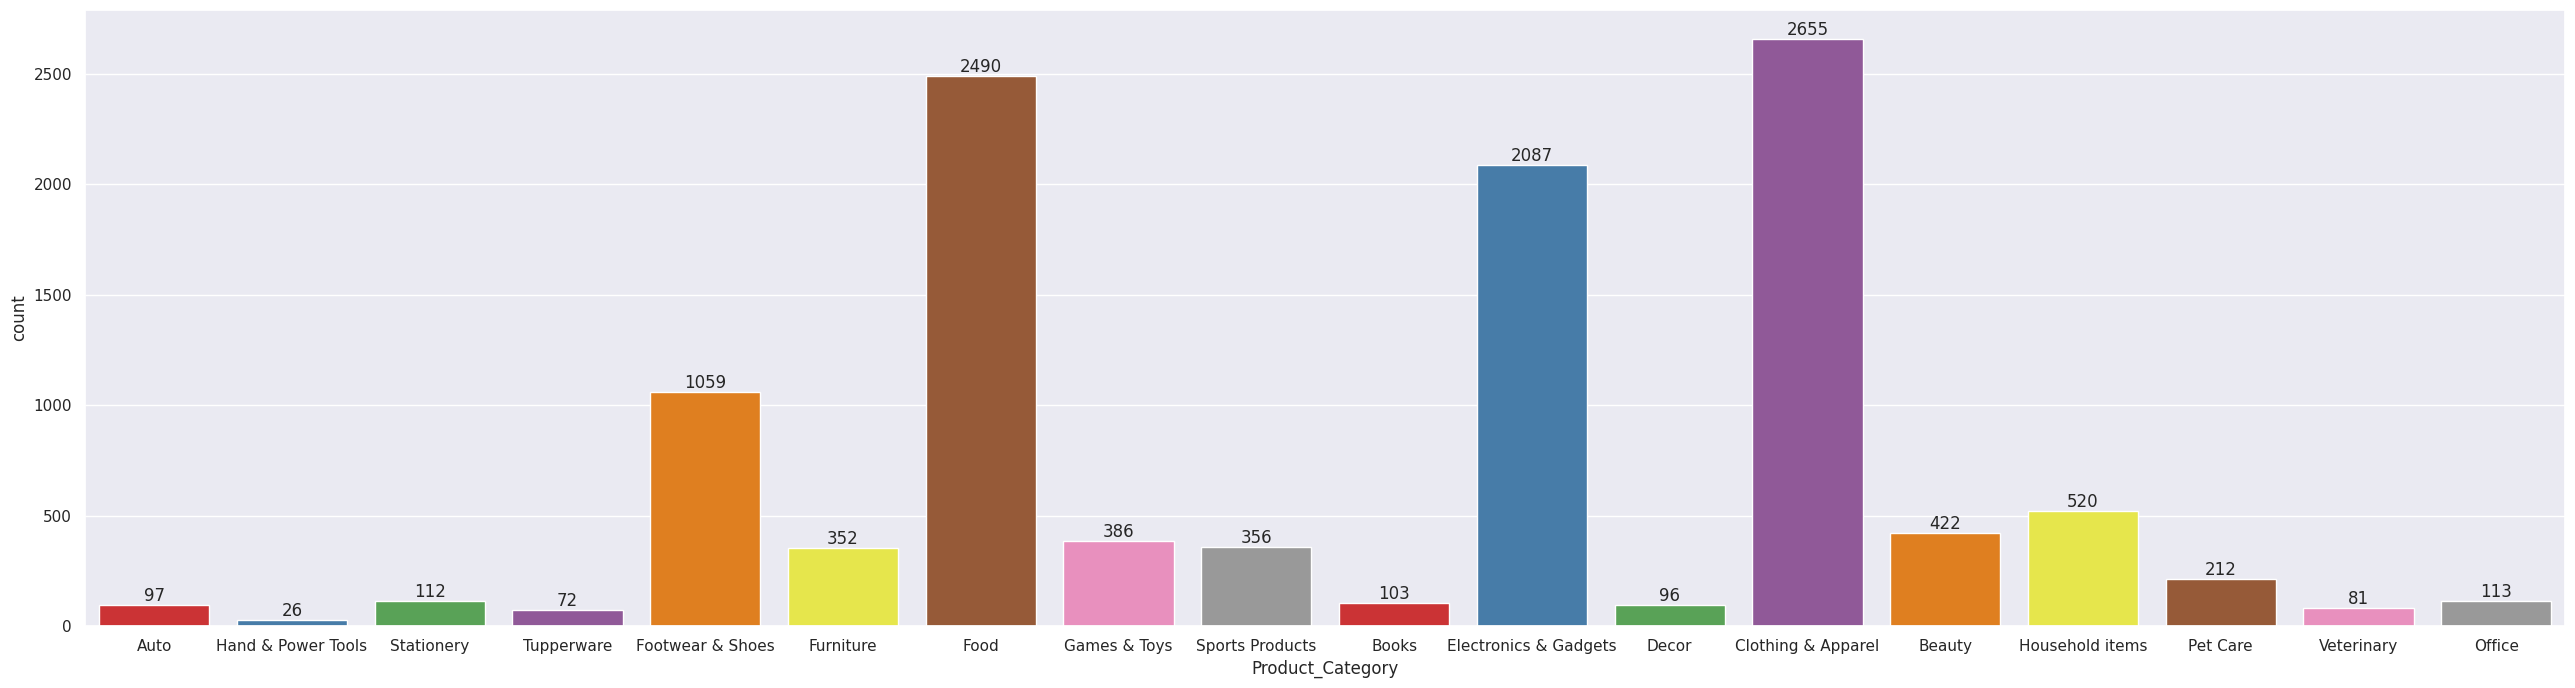

In [ ]:
ax = sns.countplot(data=df,x='Product_Category',hue='Product_Category',palette='Set1')

sns.set(rc={'figure.figsize':(32,8)})
for bars in ax.containers:
  ax.bar_label(bars)


<Axes: xlabel='Product_Category', ylabel='Amount'>

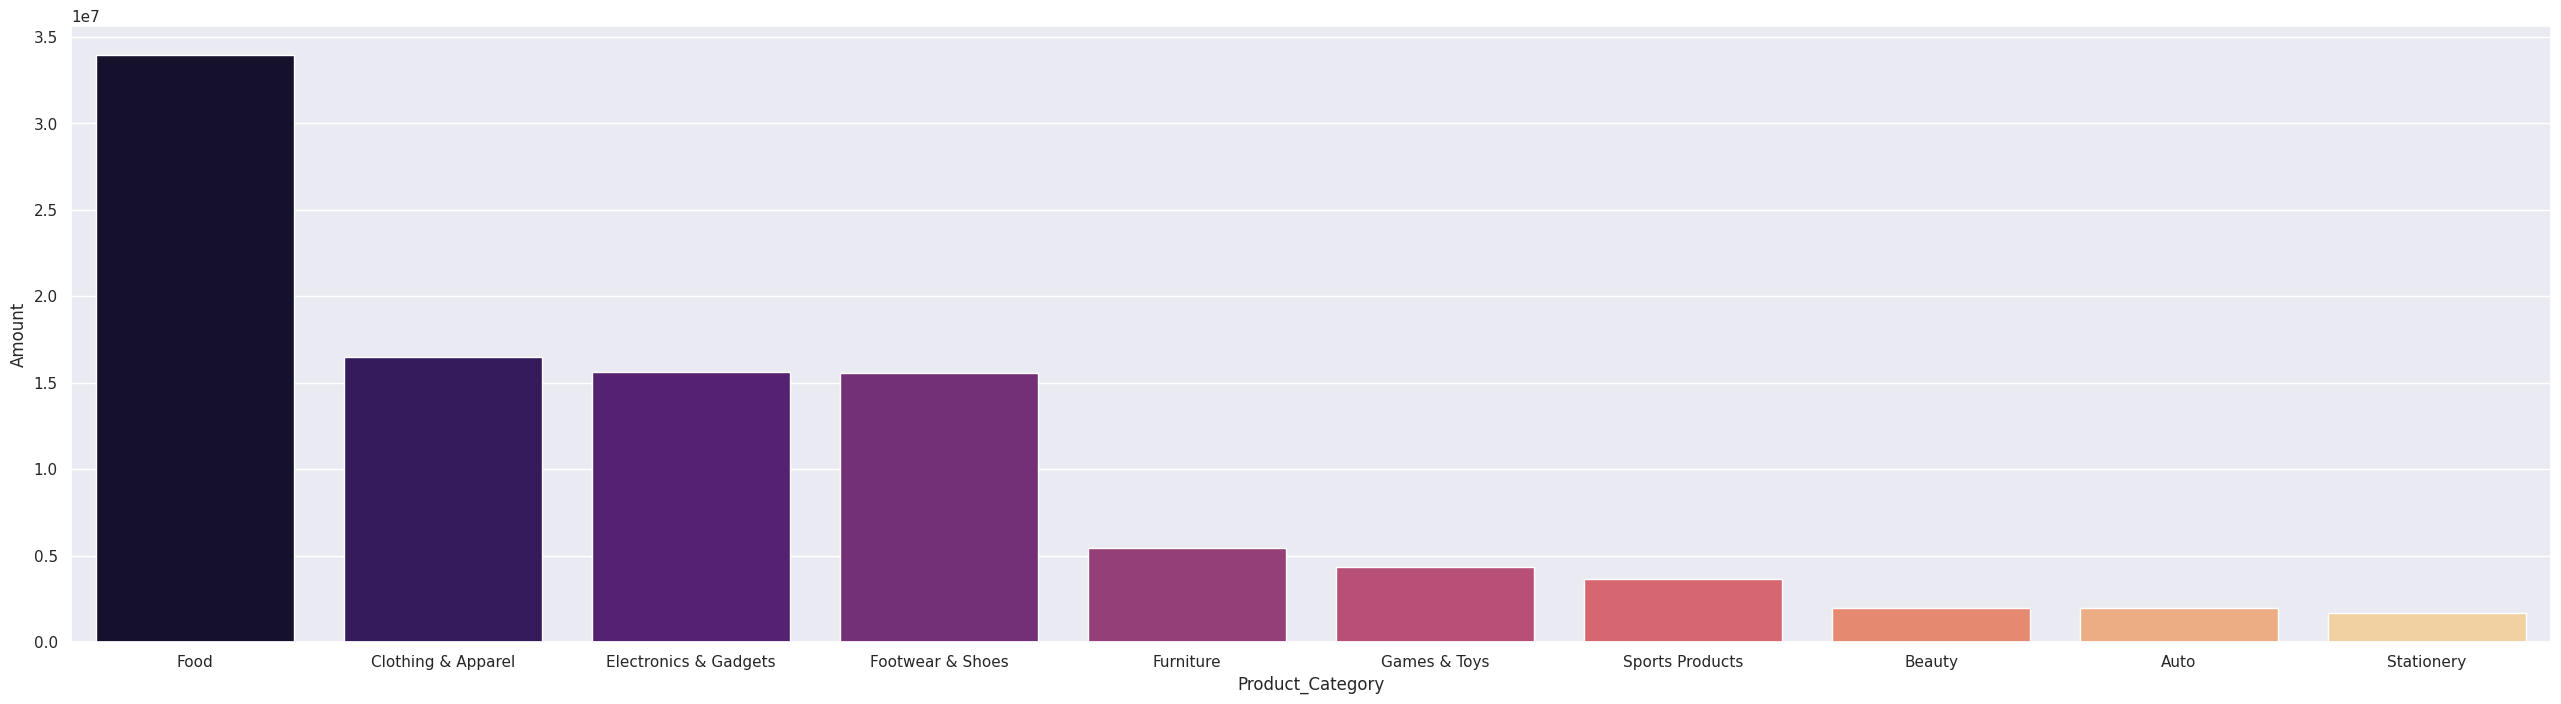

In [ ]:
sales_cat = df.groupby(['Product_Category'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)

sns.barplot(data=sales_cat,x='Product_Category',y='Amount',hue='Product_Category',palette='magma')

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics Category*

**Married women age group 26-35 yrs from UP, Maharashtra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food Cothing and Electronics Category**